# Librerias y dependencias

In [1]:
%matplotlib inline

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy import stats

from collections import Counter

# Contraste de pares consecutivos no solapados

Dada la muestra $u_1, u_2,...,u_n$, $n$ par, y un nivel de significancia $\alpha$, el test consiste en los siguientes pasos:
1. Dividir el intervalo $(0, 1)$ en $k$ clases disjuntas de la misma amplitud, $\frac{1}{k}$
2. Categorizamos la muestra $u_1, u_2,...,u_n$ asociando a cada $u_i$ el índice de la clase a la que pertenece. Sea $y_1, y_2, …, y_n$ la muestra discretizada $(y_i = j \Longleftrightarrow u_i \in C_j)$.
3. Agrupamos los valores de la muestra discretizada en pares consecutivos no solapados
$$(y_1, y_2),(y_3, y_4),...,(y_{n-1}, y_n)$$
4. Sea $O_{ij}$ el número de veces que aparece el par $(i,j)$. Si la hipótesis de uniformidad es cierta, entonces $O_{ij} \sim  Bi(\frac{n}{2}, p=\frac{1}{k^2})$. Por lo tanto, $E[O_{ij}] = E_{ij} = \frac{n}{2k^2}$
5. Se evalúa el estadístico de contraste


$$T = \sum_{i=1}^{k} \sum_{i=1}^{k} \frac{(O_{ij}-E_{ij})^2}{E_{ij}}$$

se muestra que para $n$ grande, $T$ sigue una distribución $\chi^2$ con $k^2-1$ grados de libertad.

6. Se rechaza la hipótesis de uniformidad si el estadístico  $T > \chi^2_{k^2-1, \alpha}$, donde $\chi^2_{k^2-1, \alpha}$ es el percentil de orden $1-\alpha$ de la distribución $\chi^2_{k^2-1}$

# Generador congruencial mixto

In [2]:
Xant = 45646456821    # semilla

def genRand():
    global Xant
    a = 134775813
    c = 1
    m = 2**32
    Xnext = (a * Xant + c) % m
    Xant = Xnext
    U = Xnext / m
    return U

def genRandN(N):
    U=[]
    for t in range(1, N+1):
        ui = genRand()
        U.append(ui)
    return U

# Parámetros

In [3]:
N = 10000     # cantidad de números aleatorios a generar
k = 10      # cantidad de clases disjuntas para divil el intervalo (0,1)

# Paso 0

Generar $n$ números aleatorios $u_1, u_2,...,u_n$, donde $n$ sea par,

In [4]:
U = genRandN(N)
#U = np.random.uniform(0,1,N)

print("U =" , U[0:24])

U = [0.8357941978611052, 0.5174133151303977, 0.20372454822063446, 0.6144937130156904, 0.7550783618353307, 0.09506487078033388, 0.24715944286435843, 0.8526709557045251, 0.2765643601305783, 0.48342347401194274, 0.7332439552992582, 0.2027931867633015, 0.6168847973458469, 0.0896267571952194, 0.06753929425030947, 0.2920316841918975, 0.6587222353555262, 0.8112183890771121, 0.9084181003272533, 0.015521135414019227, 0.6441075331531465, 0.44013977400027215, 0.8745229421183467, 0.5111521177459508]


# Paso 1

Dividir el intervalo $(0, 1)$ en $k$ clases disjuntas de la misma amplitud, $\frac{1}{k}$


In [5]:
incre = 1.0/k
xr = np.arange(0, 1.0, incre)

print("amplitud = ", incre)

amplitud =  0.1


In [6]:
print(xr)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


# Paso 2

Categorizamos la muestra $u_1, u_2,...,u_n$ asociando a cada $u_i$ el índice de la clase a la que pertenece. Sea $y_1, y_2, …, y_n$ la muestra discretizada $(y_i = j \Longleftrightarrow u_i \in C_j)$.


In [7]:
Y=[]

for i in range(0,len(U)):
    for j in range(k):
        if xr[j] < U[i] <= xr[j]+incre:
            Y.append(j+1)
            break
print("U =" , U[0:18])
print("Y =",Y[0:18])

U = [0.8357941978611052, 0.5174133151303977, 0.20372454822063446, 0.6144937130156904, 0.7550783618353307, 0.09506487078033388, 0.24715944286435843, 0.8526709557045251, 0.2765643601305783, 0.48342347401194274, 0.7332439552992582, 0.2027931867633015, 0.6168847973458469, 0.0896267571952194, 0.06753929425030947, 0.2920316841918975, 0.6587222353555262, 0.8112183890771121]
Y = [9, 6, 3, 7, 8, 1, 3, 9, 3, 5, 8, 3, 7, 1, 1, 3, 7, 9]


# Paso 3

Agrupamos los valores de la muestra discretizada en pares consecutivos no solapados
$$(y_1, y_2),(y_3, y_4),...,(y_{n-1}, y_n)$$


In [8]:
YP = list(zip(Y[::2], Y[1::2]))
print("YP = ",YP[0:19])

YP =  [(9, 6), (3, 7), (8, 1), (3, 9), (3, 5), (8, 3), (7, 1), (1, 3), (7, 9), (10, 1), (7, 5), (9, 6), (3, 10), (5, 2), (7, 1), (5, 4), (1, 8), (9, 4), (9, 9)]


# Paso 4

Sea $O_{ij}$ el número de veces que aparece el par $(i,j)$. Si la hipótesis de uniformidad es cierta, entonces $O_{ij} \sim  Bi(\frac{n}{2}, p=\frac{1}{k^2})$. Por lo tanto, $E[O_{ij}] = E_{ij} = \frac{n}{2k^2}$


Eij =  0.5
Oij = 
[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 3. ... 1. 1. 2.]
 [0. 1. 0. ... 1. 1. 0.]
 ...
 [0. 1. 2. ... 1. 1. 0.]
 [0. 0. 0. ... 0. 2. 2.]
 [0. 1. 0. ... 0. 0. 1.]]


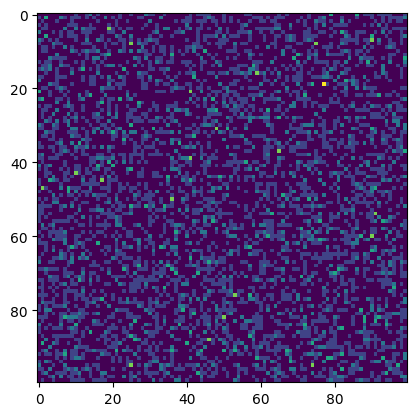

In [9]:
Eij = N/(2*(k**2))
print("Eij = ", Eij)

Oij = np.zeros( (k, k) )

Oij_keys = list(Counter(YP).keys())
Oij_values = list(Counter(YP).values())

A = np.zeros(k*2)

for i in range(len(Oij_values)):
    tup = Oij_keys[i]
    Oij[tup[0]-1][tup[1]-1] = Oij_values[i]
print("Oij = ")
print(Oij)
plt.imshow(Oij)


# Paso 5

Se evalúa el estadístico de contraste

$$T = \sum_{i=1}^{k} \sum_{i=1}^{k} \frac{(O_{ij}-E_{ij})^2}{E_{ij}}$$

se muestra que para $n$ grande, $T$ sigue una distribución $\chi^2$ con $k^2-1$ grados de libertad.


In [10]:
def chi2(O, E, dof):
    T = 0
    for i in range(dof):
        for j in range(dof):
            T = T + ( (O[i][j] - E)**2 ) /(E)
    return T

T = chi2(Oij, Eij, k)

print("Estadístico Chi^2 calculado:")
print("T = ",T)

Estadístico Chi^2 calculado:
T =  106.0


In [11]:
h,w = Oij.shape
Oij_array = np.resize(Oij,(1,h*w))[0] # redimensionamiento de Oij para enviar a libreria de scipy.stats

print("Comparación con el estadístico Chi^2 de la librería scipy.stats:")

chisq,_ = stats.chisquare(Oij_array, Eij, ddof=(k*k)-1)
print("T = ", chisq)

Comparación con el estadístico Chi^2 de la librería scipy.stats:
T =  106.0


# Paso 6

Se rechaza la hipótesis de uniformidad si el estadístico  $T > \chi^2_{k^2-1, \alpha}$, donde $\chi^2_{k^2-1, \alpha}$ es el percentil de orden $1-\alpha$ de la distribución $\chi^2_{k^2-1}$

In [12]:
alpha = 0.05
Tval = stats.chi2.ppf(1-alpha,(k**2)-1)
print("Chi^2_{k^2 - 1, alpha} = ", Tval)
print(T)

if T > Tval:
    print("Se rechaza la hipotesis de uniformidad.")
else:
    print("Se acepta la hipotesis de uniformidad.")

Chi^2_{k^2 - 1, alpha} =  123.2252214533618
106.0
Se acepta la hipotesis de uniformidad.


# Referencias

[Ríos, Ríos & Martín, 2000] David Ríos, Sixto Ríos, Jacinto Martín. Simulación, Métodos y aplicaciones. Editorial Alfaomega, 2000.